Plot generated successfully as wide_normalized_skew_matrix.pdf


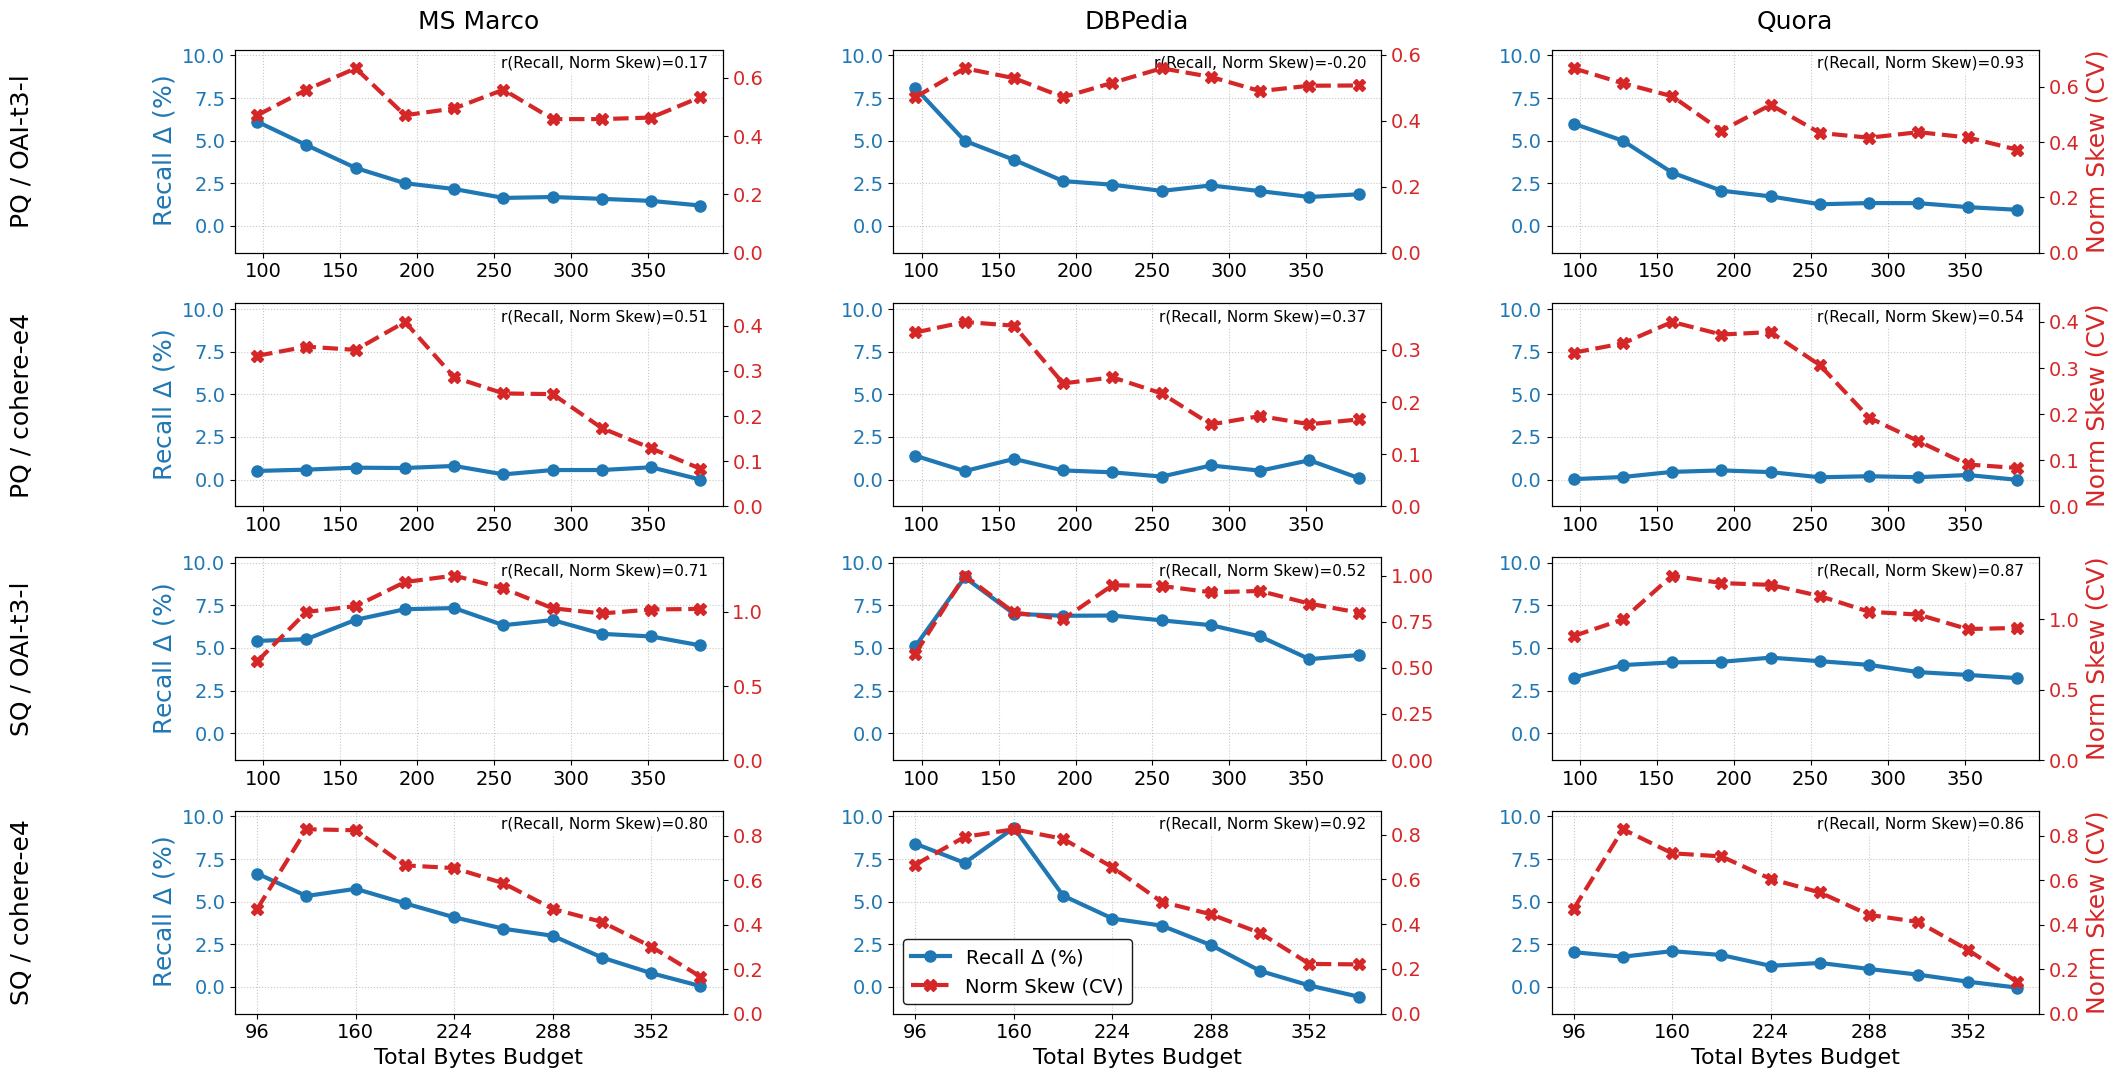

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import parse_results

# --- Global Font Settings for Academic Paper ---
plt.rcParams.update({
    'font.size': 14,          # Global font size
    'axes.titlesize': 18,     # Subplot title size
    'axes.labelsize': 16,     # X and Y axis label size
    'xtick.labelsize': 14,    # X tick numbers
    'ytick.labelsize': 14,    # Y tick numbers
    'legend.fontsize': 14,    # Legend text
    'figure.titlesize': 20    # Main figure title (if used)
})

# Total Bytes Budget
budgets = [64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384]

# --- Data (Loaded dynamically from workshop_results) ---
t1 = parse_results.get_greedy_data('PQ', 'MS Marco', 'OAI text-embed-3-l')
t2 = parse_results.get_greedy_data('PQ', 'MS Marco', 'Cohere embed-v4')
t3 = parse_results.get_greedy_data('PQ', 'DBPedia', 'OAI text-embed-3-l')
t4 = parse_results.get_greedy_data('PQ', 'DBPedia', 'Cohere embed-v4')
t5 = parse_results.get_greedy_data('PQ', 'Quora', 'OAI text-embed-3-l')
t6 = parse_results.get_greedy_data('PQ', 'Quora', 'Cohere embed-v4')

t8 = parse_results.get_greedy_data('SQ', 'DBPedia', 'OAI text-embed-3-l')
t7 = parse_results.get_greedy_data('SQ', 'DBPedia', 'Cohere embed-v4')
t9 = parse_results.get_greedy_data('SQ', 'MS Marco', 'OAI text-embed-3-l')
t10 = parse_results.get_greedy_data('SQ', 'MS Marco', 'Cohere embed-v4')
t11 = parse_results.get_greedy_data('SQ', 'Quora', 'OAI text-embed-3-l')
t12 = parse_results.get_greedy_data('SQ', 'Quora', 'Cohere embed-v4')
# --- Layout Grid ---
grid_layout = [
    [("MS Marco", t1), ("DBPedia", t3), ("Quora", t5)],
    [("MS Marco", t2), ("DBPedia", t4), ("Quora", t6)],
    [("MS Marco", t9), ("DBPedia", t8), ("Quora", t11)],
    [("MS Marco", t10), ("DBPedia", t7), ("Quora", t12)]
]

# Row labels in requested quant/model naming
row_labels = ["PQ / OAI-t3-l", "PQ / cohere-e4", "SQ / OAI-t3-l", "SQ / cohere-e4"]

# Drop points corresponding to 64-byte budget across all plots
valid_idx = [i for i, b in enumerate(budgets) if b != 64]
budgets_filtered = [budgets[i] for i in valid_idx]

# Compute global y-axis ranges so all subplots use uniform scales
all_imps = []
for row in grid_layout:
    for _, data in row:
        imps_filtered = [data['imps'][i] for i in valid_idx]
        allocs_filtered = [data['allocs'][i] for i in valid_idx]
        all_imps.extend(imps_filtered)

imp_ymin = min(all_imps) - 1
imp_ymax = max(all_imps) + 1

# WIDE ASPECT RATIO (22x11)
fig, axes = plt.subplots(4, 3, figsize=(22, 11))

for r in range(4):
    for c in range(3):
        ax = axes[r, c]
        dataset_name, data = grid_layout[r][c]
        imps = [data['imps'][i] for i in valid_idx]
        allocs = [data['allocs'][i] for i in valid_idx]

        # Calculate Coefficient of Variation (Normalized Skew)
        means = [np.mean(a) for a in allocs]
        stds = [np.std(a) for a in allocs]
        cvs = [s / m if m > 0 else 0 for s, m in zip(stds, means)]

        # Pearson correlation between Recall and Norm Skew values
        imps_arr = np.array(imps, dtype=float)
        cvs_arr = np.array(cvs, dtype=float)
        recall_skew_r = np.corrcoef(imps_arr, cvs_arr)[0, 1] if (np.std(imps_arr) > 0 and np.std(cvs_arr) > 0) else np.nan

        # Plot Primary Y-axis (Recall Delta)
        l1 = ax.plot(budgets_filtered, imps, marker='o', color='#1f77b4', linewidth=3, markersize=8, label='Recall $\\Delta$ (%)')
        if c == 0:
            ax.set_ylabel('Recall $\\Delta$ (%)', color='#1f77b4', fontsize=18)
        else:
            ax.set_ylabel('')
        ax.tick_params(axis='y', labelcolor='#1f77b4')
        ax.set_ylim(imp_ymin, imp_ymax)

        # Plot Secondary Y-axis (Normalized Skew)
        ax_twin = ax.twinx()
        l2 = ax_twin.plot(budgets_filtered, cvs, marker='X', color='#d62728', linestyle='--', linewidth=3, markersize=8, label='Norm Skew (CV)')
        if c == 2:
            ax_twin.set_ylabel('Norm Skew (CV)', color='#d62728', fontsize=18)
        else:
            ax_twin.set_ylabel('')
        ax_twin.tick_params(axis='y', labelcolor='#d62728')
        cv_ymax_local = max(cvs) * 1.1 if max(cvs) > 0 else 1
        ax_twin.set_ylim(0, cv_ymax_local)

        # Show Pearson r(Recall, Norm Skew) in each subplot
        ax.text(
            0.97,
            0.97,
            f"r(Recall, Norm Skew)={recall_skew_r:.2f}",
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75, edgecolor='none')
        )

        # Formatting
        if r == 0:
            ax.set_title(dataset_name, pad=15)

        if c == 0:
            ax.annotate(row_labels[r], xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 80, 0),
                        xycoords=ax.yaxis.label, textcoords='offset points',
                        size=18, ha='right', va='center', rotation=90)

        if r == 3:
            ax.set_xlabel('Total Bytes Budget')
            ax.set_xticks(budgets_filtered[::2])  # Show every other budget to prevent x-axis crowding

        ax.grid(True, linestyle=':', alpha=0.7)

        # Unified Legend (Only in bottom-middle subplot)
        if r == 3 and c == 1:
            lns = l1 + l2
            labs = [l.get_label() for l in lns]
            ax.legend(lns, labs, loc='lower left', framealpha=0.9, edgecolor='black')

plt.tight_layout()
fig.subplots_adjust(left=0.10, right=0.92, wspace=0.35, hspace=0.25)
plt.savefig('wide_normalized_skew_matrix.pdf', dpi=300, bbox_inches='tight')
print("Plot generated successfully as wide_normalized_skew_matrix.pdf")

Plot generated successfully as wide_normalized_skew_matrix_no_pearson.pdf


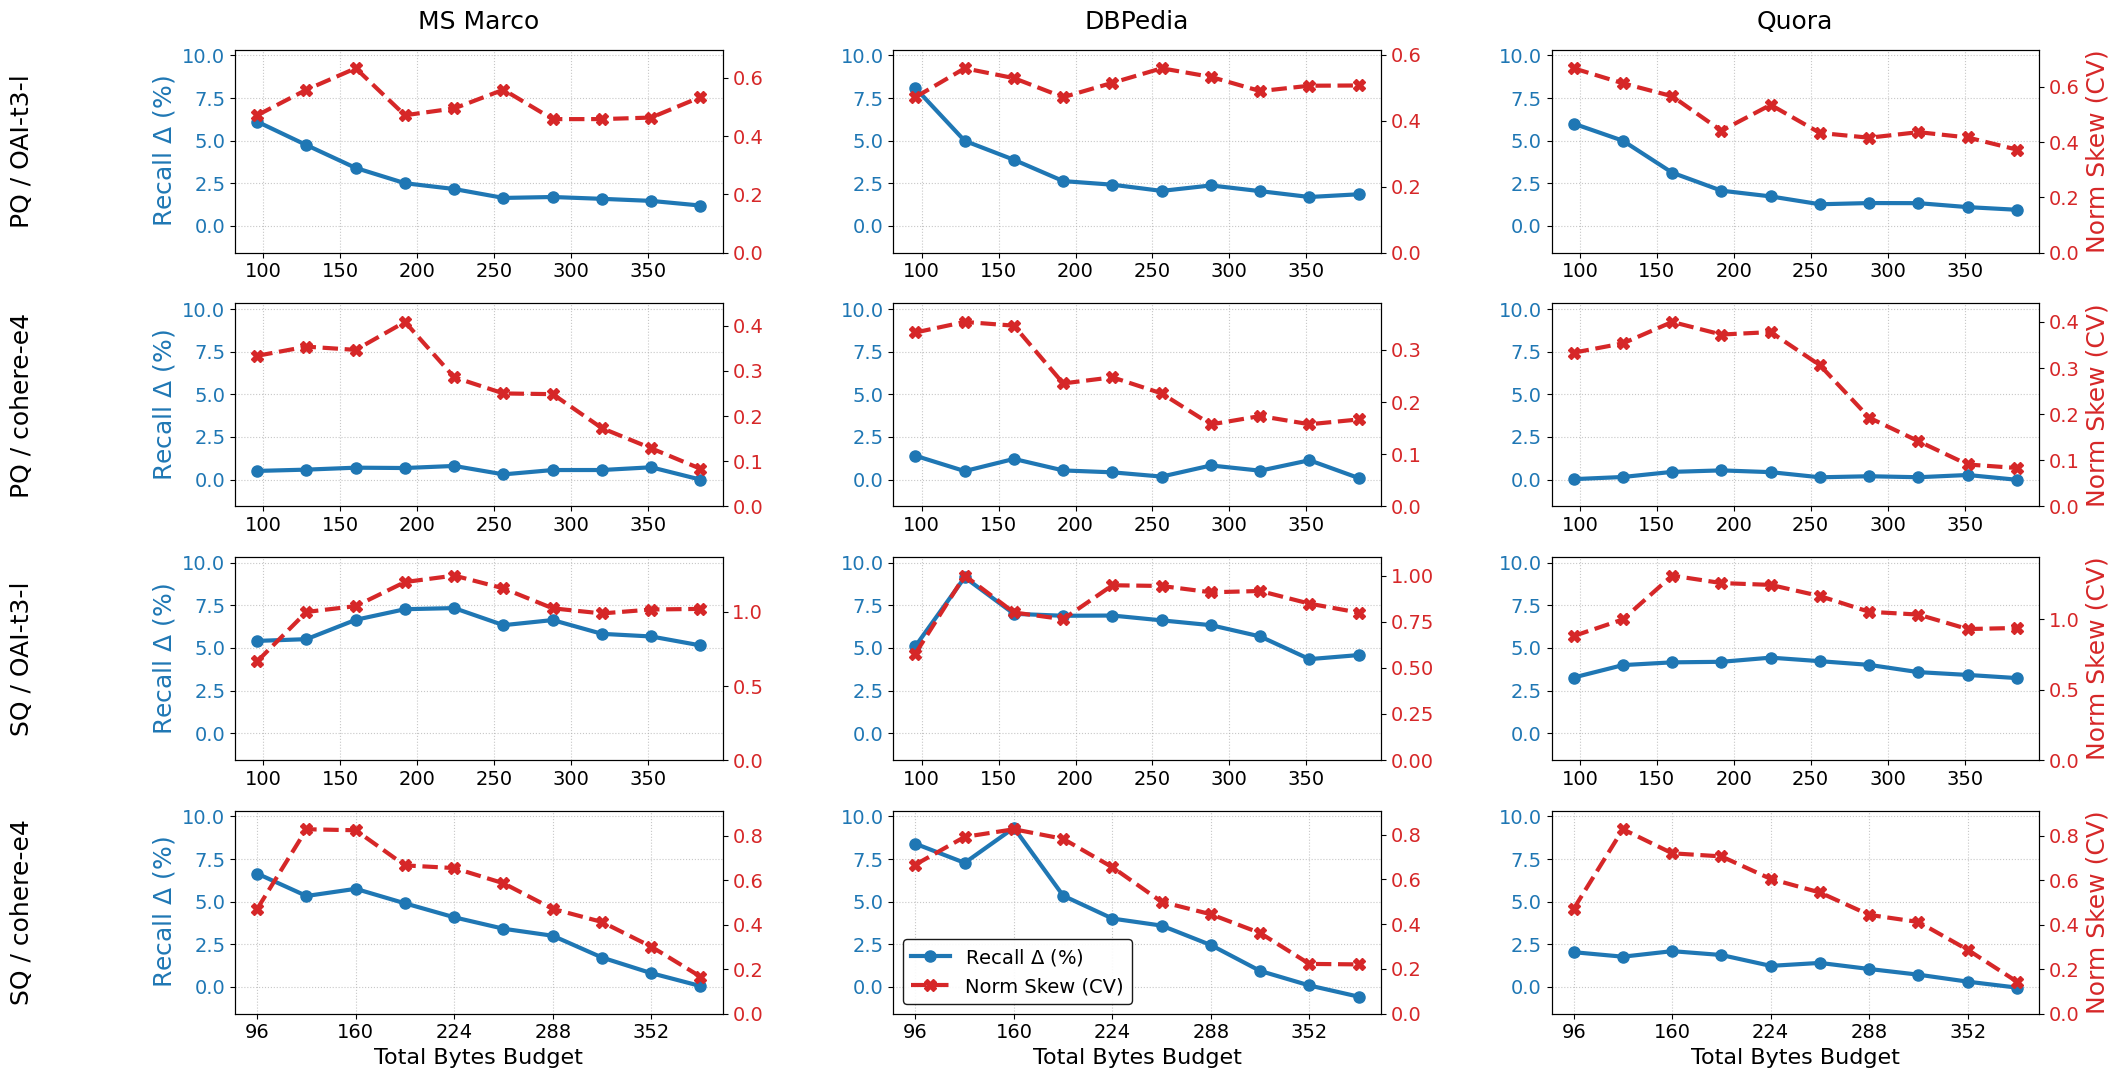

In [2]:
# Version without Pearson coefficient annotations (keeps original figure code untouched)
fig_np, axes_np = plt.subplots(4, 3, figsize=(22, 11))

for r in range(4):
    for c in range(3):
        ax = axes_np[r, c]
        dataset_name, data = grid_layout[r][c]
        imps = [data['imps'][i] for i in valid_idx]
        allocs = [data['allocs'][i] for i in valid_idx]

        means = [np.mean(a) for a in allocs]
        stds = [np.std(a) for a in allocs]
        cvs = [s / m if m > 0 else 0 for s, m in zip(stds, means)]

        l1 = ax.plot(
            budgets_filtered,
            imps,
            marker='o',
            color='#1f77b4',
            linewidth=3,
            markersize=8,
            label='Recall $\\Delta$ (%)'
        )
        if c == 0:
            ax.set_ylabel('Recall $\\Delta$ (%)', color='#1f77b4', fontsize=18)
        else:
            ax.set_ylabel('')
        ax.tick_params(axis='y', labelcolor='#1f77b4')
        ax.set_ylim(imp_ymin, imp_ymax)

        ax_twin = ax.twinx()
        l2 = ax_twin.plot(
            budgets_filtered,
            cvs,
            marker='X',
            color='#d62728',
            linestyle='--',
            linewidth=3,
            markersize=8,
            label='Norm Skew (CV)'
        )
        if c == 2:
            ax_twin.set_ylabel('Norm Skew (CV)', color='#d62728', fontsize=18)
        else:
            ax_twin.set_ylabel('')
        ax_twin.tick_params(axis='y', labelcolor='#d62728')
        cv_ymax_local = max(cvs) * 1.1 if max(cvs) > 0 else 1
        ax_twin.set_ylim(0, cv_ymax_local)

        if r == 0:
            ax.set_title(dataset_name, pad=15)

        if c == 0:
            ax.annotate(
                row_labels[r],
                xy=(0, 0.5),
                xytext=(-ax.yaxis.labelpad - 80, 0),
                xycoords=ax.yaxis.label,
                textcoords='offset points',
                size=18,
                ha='right',
                va='center',
                rotation=90
            )

        if r == 3:
            ax.set_xlabel('Total Bytes Budget')
            ax.set_xticks(budgets_filtered[::2])

        ax.grid(True, linestyle=':', alpha=0.7)

        # Unified Legend (Only in bottom-middle subplot)
        if r == 3 and c == 1:
            lns = l1 + l2
            labs = [l.get_label() for l in lns]
            ax.legend(lns, labs, loc='lower left', framealpha=0.9, edgecolor='black')

plt.tight_layout()
fig_np.subplots_adjust(left=0.10, right=0.92, wspace=0.35, hspace=0.25)
plt.savefig('wide_normalized_skew_matrix_no_pearson.pdf', dpi=300, bbox_inches='tight')
print("Plot generated successfully as wide_normalized_skew_matrix_no_pearson.pdf")

Plot generated successfully as wide_bit_allocations_heatmap.pdf


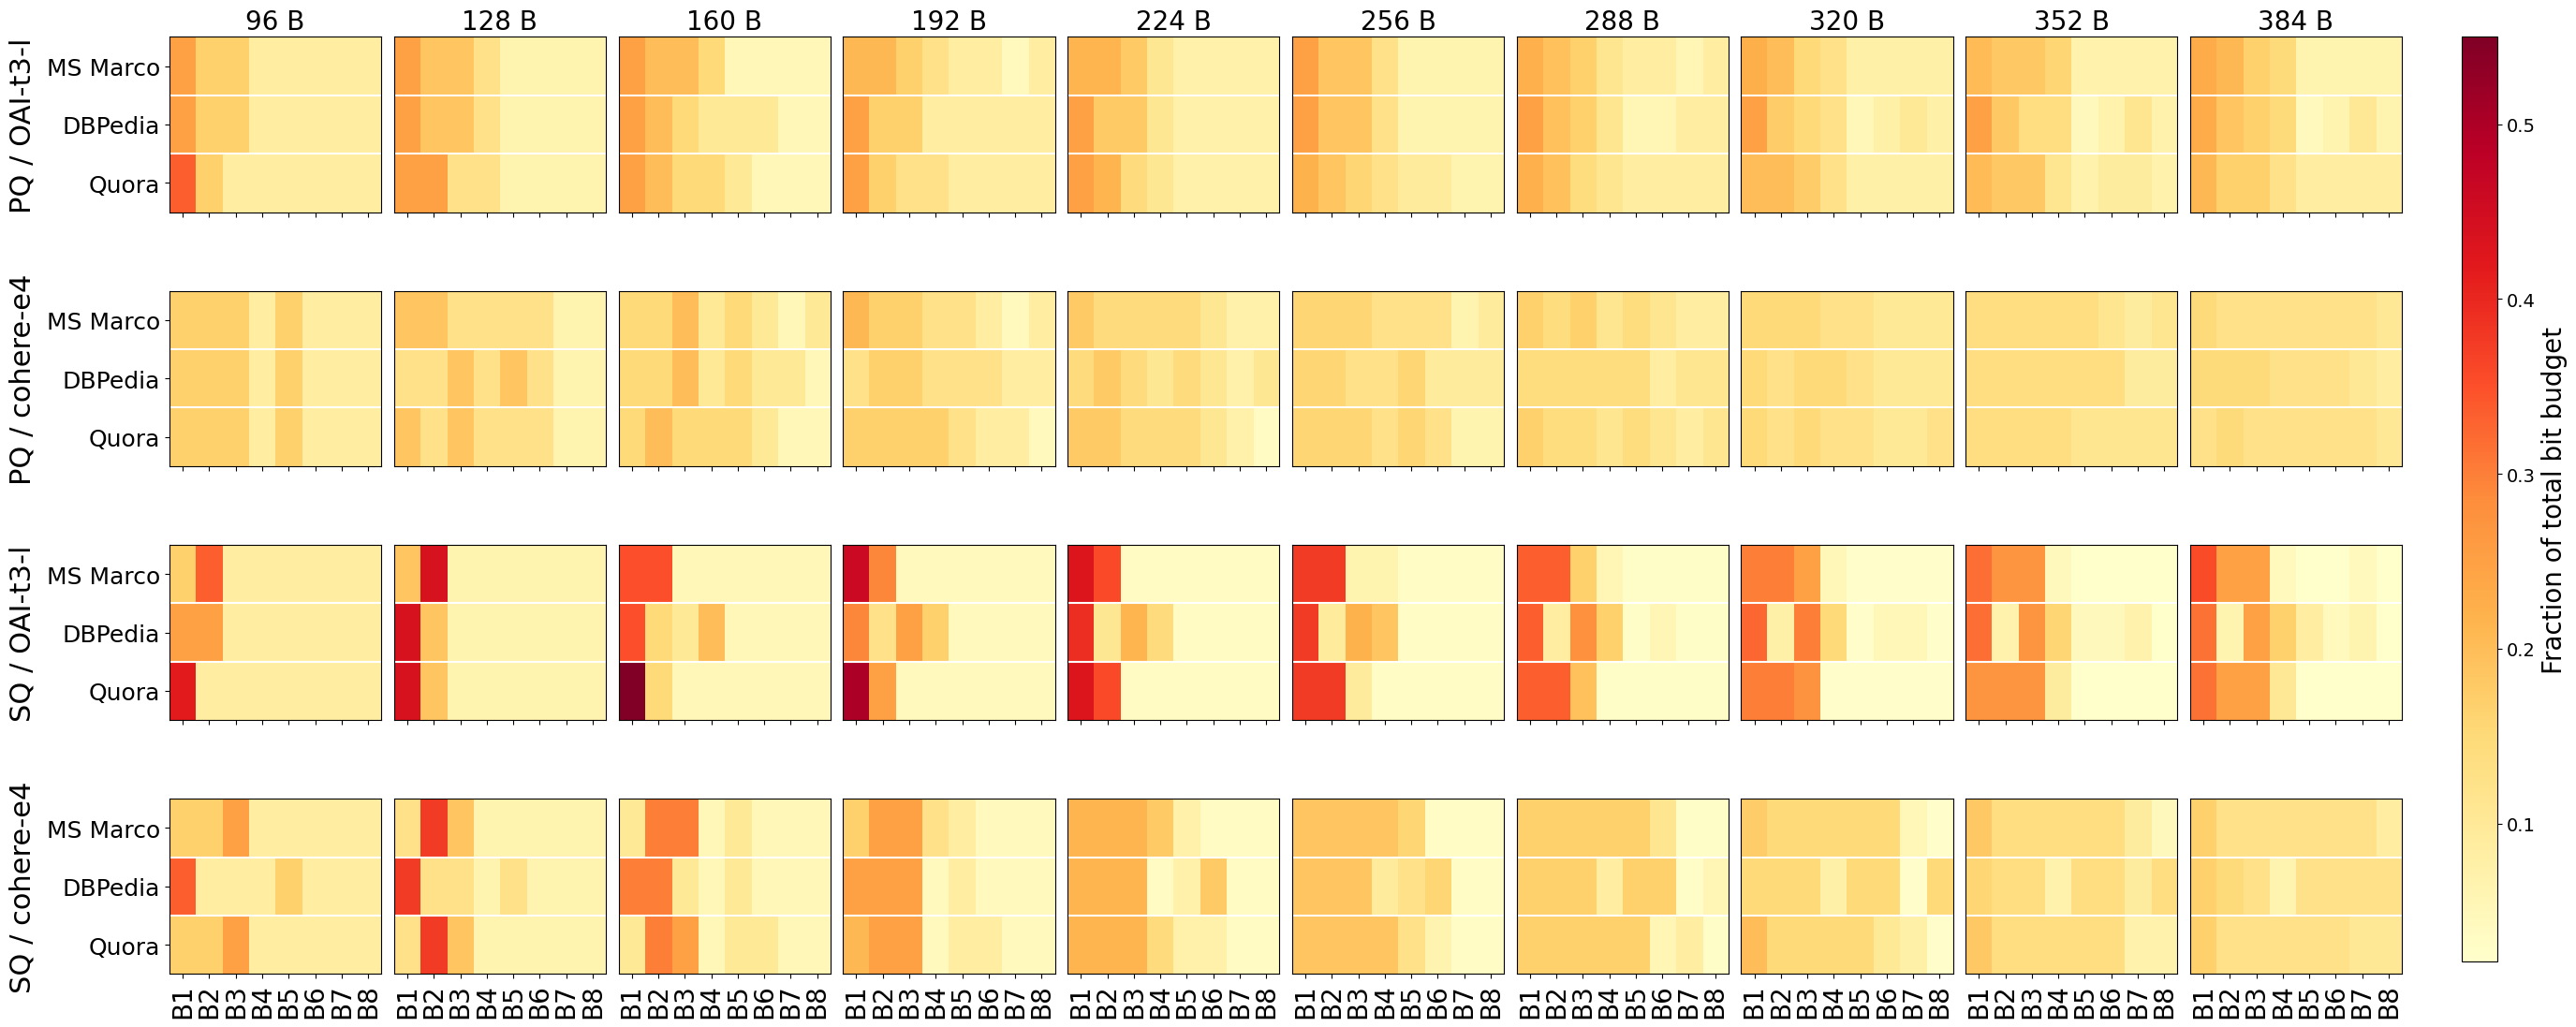

In [5]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Bit-allocation heatmap, split by quantizer × model ---
# Layout: 4 rows (quant/model) × 10 cols (budget), each cell = 3 datasets × 8 subspaces.

dataset_names = ["MS Marco", "DBPedia", "Quora"]   # columns within grid_layout rows

# quant/model groups: (label, row index in grid_layout)
qm_rows = [
    ("PQ / OAI-t3-l", 0),
    ("PQ / cohere-e4", 1),
    ("SQ / OAI-t3-l",  2),
    ("SQ / cohere-e4", 3),
]
n_qm = len(qm_rows)           # 4
n_budgets_f = len(budgets_filtered)  # 10

# Global colour scale after normalizing by total bit budget
global_min = min(
    v / budgets[idx] for _, r_idx in qm_rows
    for ds_i in range(3)
    for idx in valid_idx
    for v in grid_layout[r_idx][ds_i][1]['allocs'][idx]
)
global_max = max(
    v / budgets[idx] for _, r_idx in qm_rows
    for ds_i in range(3)
    for idx in valid_idx
    for v in grid_layout[r_idx][ds_i][1]['allocs'][idx]
)
cmap_hm = cm.YlOrRd
norm_hm = mcolors.Normalize(vmin=global_min, vmax=global_max)

fig_hm2, axes_hm2 = plt.subplots(
    n_qm, n_budgets_f,
    figsize=(32, 13),
    gridspec_kw={'wspace': 0.06, 'hspace': 0.45}
)

for qm_i, (qm_label, row_idx) in enumerate(qm_rows):
    for budget_i, orig_idx in enumerate(valid_idx):
        ax = axes_hm2[qm_i, budget_i]

        # 3-row matrix: one row per dataset
        matrix = np.array([
            grid_layout[row_idx][ds_i][1]['allocs'][orig_idx]
            for ds_i in range(3)
        ], dtype=float) / budgets[orig_idx]

        ax.imshow(matrix, aspect='auto', cmap=cmap_hm, norm=norm_hm,
                  interpolation='nearest')

        # --- NEW CODE: Add mild separation between dataset rows ---
        # Draw white dividing lines between row 0 & 1 (at y=0.5) and row 1 & 2 (at y=1.5)
        for y_border in [0.5, 1.5]:
            ax.axhline(y_border, color='white', linewidth=1.5)

        # Budget label on top row
        if qm_i == 0:
            ax.set_title(f'{budgets_filtered[budget_i]} B', fontsize=20)

        # Subspace tick labels on bottom row
        ax.set_xticks(range(8))
        if qm_i == n_qm - 1:
            ax.set_xticklabels([f'B{i+1}' for i in range(8)], fontsize=20, rotation=90, ha='center', va='top')
        else:
            ax.set_xticklabels([])

        # Dataset row labels + quant/model label on left column
        if budget_i == 0:
            ax.set_yticks(range(3))
            ax.set_yticklabels(dataset_names, fontsize=18)
            ax.set_ylabel(qm_label, fontsize=22, labelpad=8)
        else:
            ax.set_yticks([])

# Shared colourbar on the right
fig_hm2.subplots_adjust(right=0.87)
cbar_ax2 = fig_hm2.add_axes([0.89, 0.12, 0.012, 0.76])
sm2 = cm.ScalarMappable(cmap=cmap_hm, norm=norm_hm)
sm2.set_array([])
cbar2 = fig_hm2.colorbar(sm2, cax=cbar_ax2)
cbar2.set_label('Fraction of total bit budget', fontsize=20)

plt.savefig('wide_bit_allocations_heatmap.pdf', dpi=300, bbox_inches='tight')
print("Plot generated successfully as wide_bit_allocations_heatmap.pdf")

Plot generated successfully as uniform_bit_allocation_recall.pdf


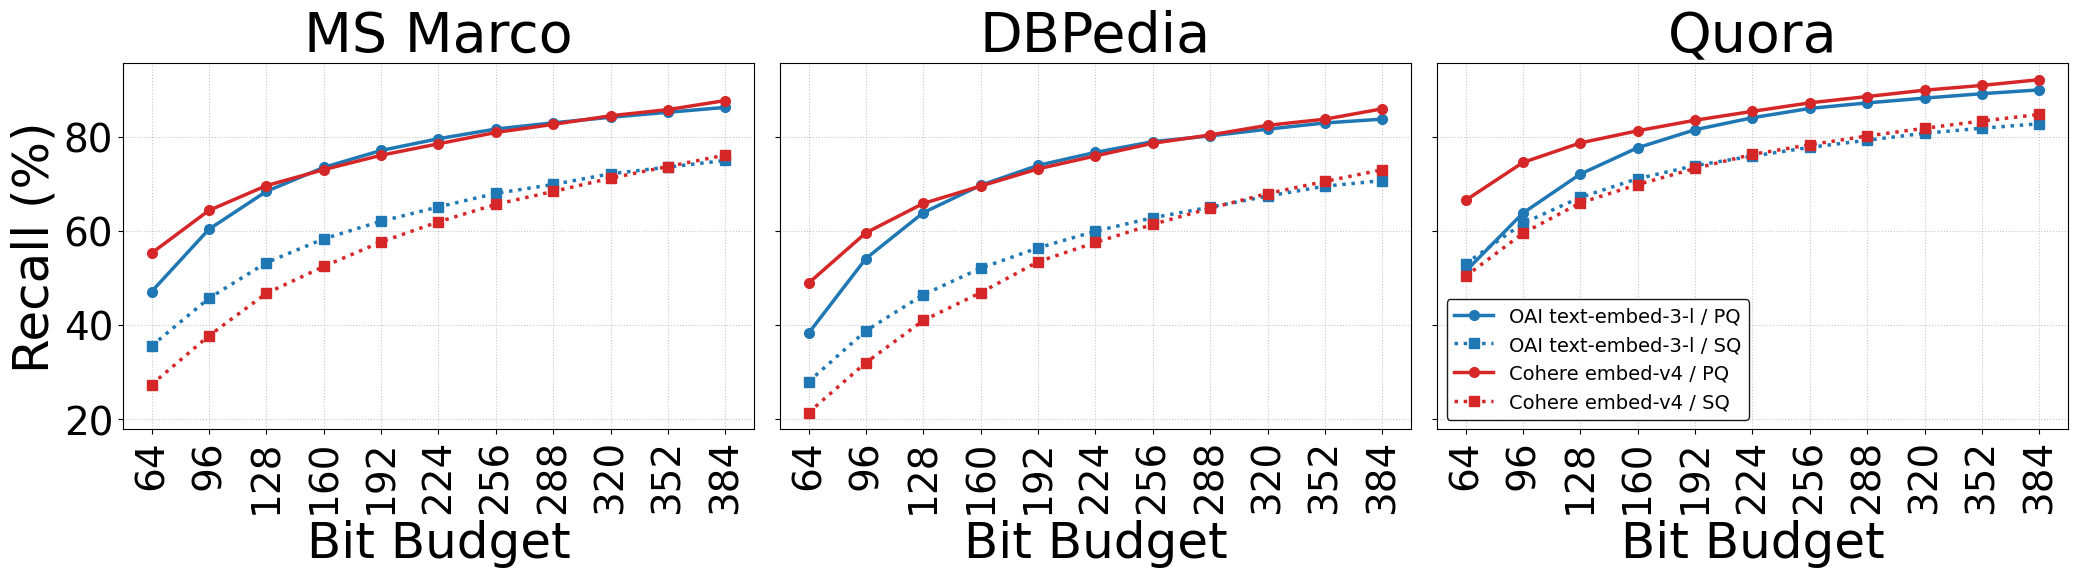

In [4]:
# Uniform bit allocation recall plots
# Three charts: one per dataset.
# Same color for the same model, different markers for PQ vs SQ.

import parse_results

uniform_recall_raw = {
    'PQ': {
        'OAI text-embed-3-l': {
            'MS Marco': parse_results.get_uniform_recalls('PQ', 'MS Marco', 'OAI text-embed-3-l'),
            'DBPedia': parse_results.get_uniform_recalls('PQ', 'DBPedia', 'OAI text-embed-3-l'),
            'Quora': parse_results.get_uniform_recalls('PQ', 'Quora', 'OAI text-embed-3-l'),
        },
        'Cohere embed-v4': {
            'MS Marco': parse_results.get_uniform_recalls('PQ', 'MS Marco', 'Cohere embed-v4'),
            'DBPedia': parse_results.get_uniform_recalls('PQ', 'DBPedia', 'Cohere embed-v4'),
            'Quora': parse_results.get_uniform_recalls('PQ', 'Quora', 'Cohere embed-v4'),
        },
    },
    'SQ': {
        'OAI text-embed-3-l': {
            'MS Marco': parse_results.get_uniform_recalls('SQ', 'MS Marco', 'OAI text-embed-3-l'),
            'DBPedia': parse_results.get_uniform_recalls('SQ', 'DBPedia', 'OAI text-embed-3-l'),
            'Quora': parse_results.get_uniform_recalls('SQ', 'Quora', 'OAI text-embed-3-l'),
        },
        'Cohere embed-v4': {
            'MS Marco': parse_results.get_uniform_recalls('SQ', 'MS Marco', 'Cohere embed-v4'),
            'DBPedia': parse_results.get_uniform_recalls('SQ', 'DBPedia', 'Cohere embed-v4'),
            'Quora': parse_results.get_uniform_recalls('SQ', 'Quora', 'Cohere embed-v4'),
        },
    },
}

plot_budgets = budgets
datasets = ['MS Marco', 'DBPedia', 'Quora']
model_colors = {
    'OAI text-embed-3-l': '#1f77b4',
    'Cohere embed-v4': '#d62728',
}
quantizer_markers = {
    'PQ': 'o',
    'SQ': 's',
}
quantizer_linestyles = {
    'PQ': '-',
    'SQ': ':',
}

fig_uniform, axes_uniform = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

for ax, dataset in zip(axes_uniform, datasets):
    for model_name in ['OAI text-embed-3-l', 'Cohere embed-v4']:
        for quantizer in ['PQ', 'SQ']:
            ax.plot(
                plot_budgets,
                uniform_recall_raw[quantizer][model_name][dataset],
                marker=quantizer_markers[quantizer],
                linestyle=quantizer_linestyles[quantizer],
                linewidth=2.5,
                markersize=7,
                color=model_colors[model_name],
                label=f'{model_name} / {quantizer}',
            )

    ax.set_title(dataset, fontsize=40)
    ax.set_xlabel('Bit Budget', fontsize=36)
    ax.set_xticks(plot_budgets)
    ax.tick_params(axis='x', labelsize=28)
    ax.tick_params(axis='y', labelsize=28)
    ax.set_xticklabels(plot_budgets, rotation=90, ha='center', va='top')
    ax.grid(True, linestyle=':', alpha=0.7)

axes_uniform[0].set_ylabel('Recall (%)', fontsize=36)
axes_uniform[2].legend(loc='best', framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.savefig('uniform_bit_allocation_recall.pdf', dpi=300, bbox_inches='tight')
print('Plot generated successfully as uniform_bit_allocation_recall.pdf')